# Task 1 — Time-Series Preprocessing, EDA & Modeling
### Appliances Energy Prediction dataset (UCI)
**Author: Jeremie Iyamurinze**

This notebook covers Task 1 of the pipeline:
- **1A** Understanding the dataset (time range, granularity, missing values, distributions)
- **1B** Five+ analytical questions with visualizations and interpretation (including **lag features** and **moving averages**)
- **1C** Feature engineering, then training and tuning models with an experiment table

Shared preprocessing lives in `preprocessing.py` so the **Task 4 prediction script reuses the exact same pipeline**.

In [1]:
import os, sys
sys.path.append(os.path.abspath('.'))            # so `preprocessing` and `config` import
sys.path.append(os.path.abspath('..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid')

from preprocessing import (load_raw, build_features, chronological_split,
                           TARGET, SENSOR_COLS, LAGS, ROLL_WINDOWS)
pd.set_option('display.max_columns', 40)

## 1A. Understanding the dataset

In [2]:
df = load_raw()
print('Shape:', df.shape)
print('Time range :', df.index.min(), '->', df.index.max(),
      f'({(df.index.max()-df.index.min()).days} days)')
print('Granularity:', df.index.to_series().diff().median(), '(regular 10-minute sampling)')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jeremieiyamurinze/ALU/Pipeline-for-Time-Series-Data-1/data/raw/energydata_complete.csv'

**Frequency / granularity.** Readings are spaced **10 minutes** apart, so 6 steps = 1 hour and 144 steps = 1 day. This regular spacing is what makes lag and rolling-window features meaningful.

In [ ]:
# Missing values
missing = df.isna().sum()
print('Total missing values:', int(missing.sum()))
missing[missing > 0]

Total missing values: 0


Series([], dtype: int64)

**Missing values & how we handle them.** The raw dataset is complete (0 missing). Real sensor feeds do drop readings, so the preprocessing pipeline still defends against gaps by **sorting on the timestamp** and, where needed, using **time-based forward fill / interpolation** (chosen over dropping rows because a time series must stay evenly spaced — deleting rows would break the 10-minute cadence that the lag/rolling features rely on).

In [ ]:
# Statistical distribution of numerical columns
desc = df.describe().T[['mean','std','min','25%','50%','75%','max']]
desc.round(2).head(12)

,mean,std,min,25%,50%,75%,max
Appliances,97.69,102.52,10.00,50.00,60.00,100.00,1080.00
lights,3.80,7.94,0.00,0.00,0.00,0.00,70.00
T1,21.69,1.61,16.79,20.76,21.60,22.60,26.26
RH_1,40.26,3.98,27.02,37.33,39.66,43.07,63.36
T2,20.34,2.19,16.10,18.79,20.00,21.50,29.86
RH_2,40.42,4.07,20.46,37.90,40.50,43.26,56.03
T3,22.27,2.01,17.20,20.79,22.10,23.29,29.24
RH_3,39.24,3.25,28.77,36.90,38.53,41.76,50.16
T4,20.86,2.04,15.10,19.53,20.67,22.10,26.20
RH_4,39.03,4.34,27.66,35.53,38.40,42.16,51.09


## 1B. Analytical questions

We answer **7 questions**, each with a visualization and interpretation. Q5 uses **lag features** and Q6 uses **moving averages** (the two required types).

### Q1. Does appliance energy use show a trend or seasonality over time?

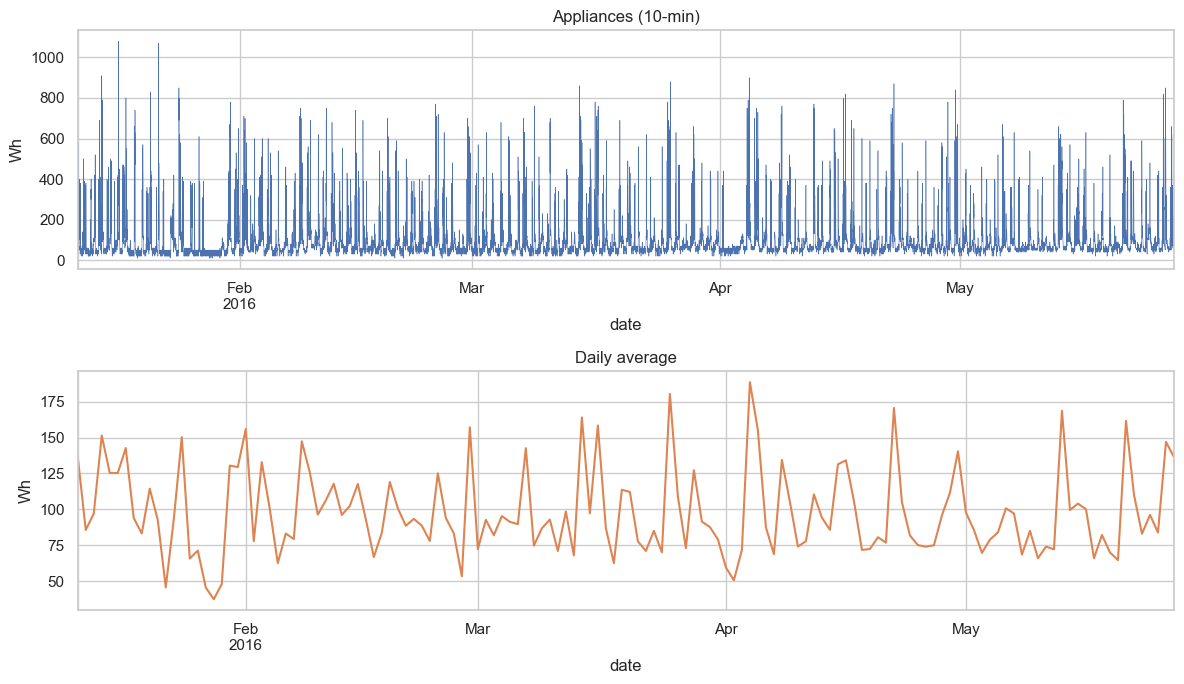

In [ ]:
daily = df[TARGET].resample('D').mean()
fig, ax = plt.subplots(2,1, figsize=(12,7))
df[TARGET].plot(ax=ax[0], lw=0.4, color='#4C72B0'); ax[0].set(title='Appliances (10-min)', ylabel='Wh')
daily.plot(ax=ax[1], color='#DD8452'); ax[1].set(title='Daily average', ylabel='Wh')
plt.tight_layout(); plt.show()

**Interpretation.** There is **no strong long-term trend**; instead the series is dominated by **repeating daily cycles** with frequent short spikes. The daily-average panel is fairly flat across the 4.5 months, confirming the signal is mostly *seasonal/behavioural* (daily routine) rather than trending — which tells us short-horizon lag features will be far more useful than a linear time trend.

### Q2. What is the statistical distribution of the target?

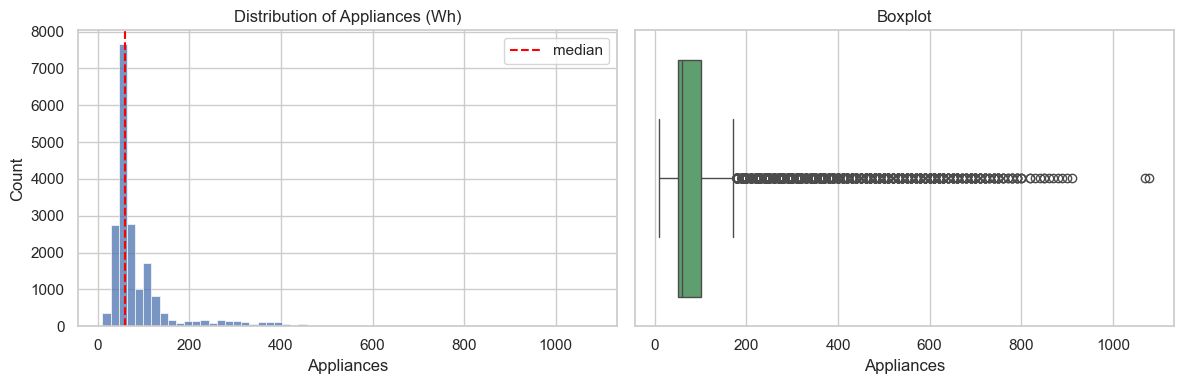

Skewness: 3.39 | median: 60.0 | max: 1080


In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(df[TARGET], bins=60, ax=ax[0], color='#4C72B0')
ax[0].axvline(df[TARGET].median(), color='red', ls='--', label='median'); ax[0].legend()
ax[0].set_title('Distribution of Appliances (Wh)')
sns.boxplot(x=df[TARGET], ax=ax[1], color='#55A868'); ax[1].set_title('Boxplot')
plt.tight_layout(); plt.show()
print('Skewness:', round(df[TARGET].skew(),2), '| median:', df[TARGET].median(), '| max:', df[TARGET].max())

**Interpretation.** Appliances is **strongly right-skewed (skew ≈ 3.4)**: most 10-minute readings sit at 10–100 Wh (median 60), with occasional spikes up to 1080 Wh when high-power appliances run. This matters for modeling — errors will be driven by the rare high-usage events, so we track **MAE and RMSE** together (RMSE punishes the big misses).

### Q3. Which variables correlate most with energy use?

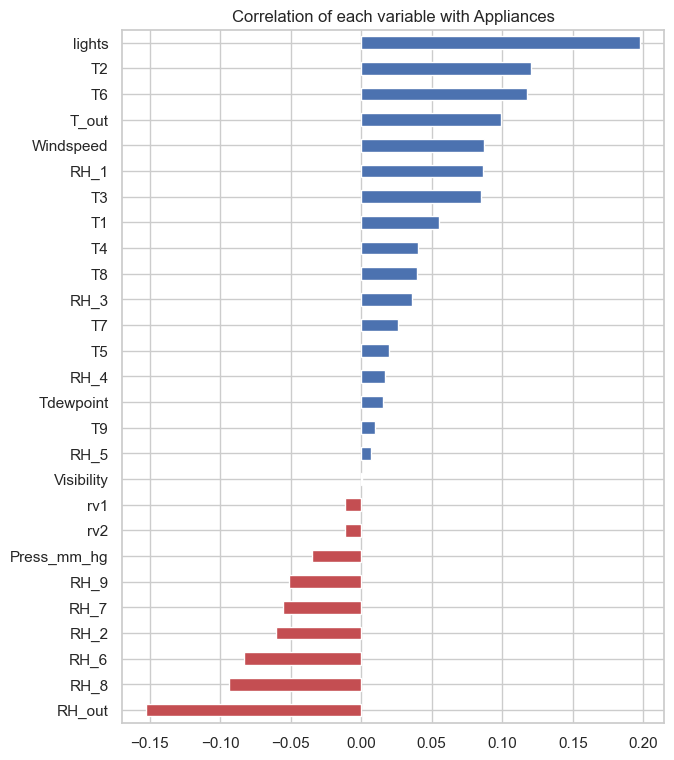

lights    0.197278
RH_out    0.152282
T2        0.120073
T6        0.117638
T_out     0.099155
RH_8      0.094039
Name: Appliances, dtype: float64

In [ ]:
corr = df.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(7,9))
corr.plot.barh(ax=ax, color=np.where(corr>=0,'#4C72B0','#C44E52'))
ax.set_title(f'Correlation of each variable with {TARGET}'); plt.show()
corr.abs().sort_values(ascending=False).head(6)

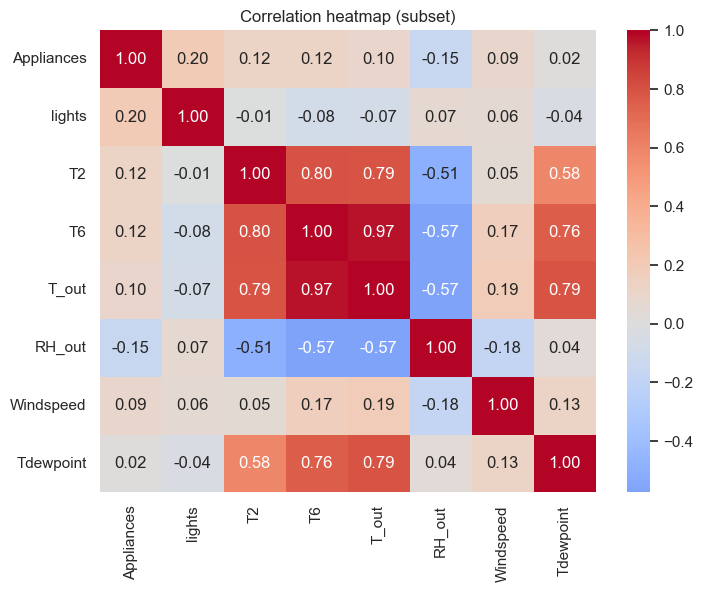

In [ ]:
subset=[TARGET,'lights','T2','T6','T_out','RH_out','Windspeed','Tdewpoint']
plt.figure(figsize=(8,6))
sns.heatmap(df[subset].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap (subset)'); plt.show()

**Interpretation.** Correlations with the raw target are **modest** — `lights` (r≈0.20), outdoor humidity `RH_out` (≈0.15) and indoor temps `T2`/`T6` (≈0.12) are the strongest. No single sensor explains usage, which is expected for human-driven consumption. The heatmap also shows the indoor temperatures are highly correlated *with each other* (multicollinearity). Because linear correlation is weak, a **non-linear model (Random Forest)** plus **lag features** should beat a purely linear approach — a hypothesis we test in 1C.

### Q4. How does usage vary by hour of day and day of week?

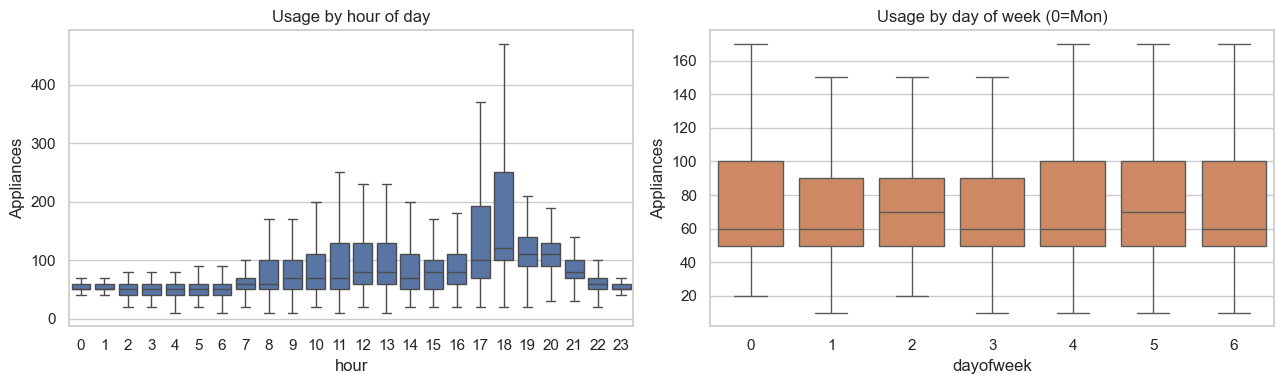

Peak hour: 18


In [ ]:
d = df.copy(); d['hour']=d.index.hour; d['dayofweek']=d.index.dayofweek
fig, ax = plt.subplots(1,2, figsize=(13,4))
sns.boxplot(data=d, x='hour', y=TARGET, ax=ax[0], color='#4C72B0', showfliers=False)
ax[0].set_title('Usage by hour of day')
sns.boxplot(data=d, x='dayofweek', y=TARGET, ax=ax[1], color='#DD8452', showfliers=False)
ax[1].set_title('Usage by day of week (0=Mon)')
plt.tight_layout(); plt.show()
print('Peak hour:', d.groupby('hour')[TARGET].mean().idxmax())

**Interpretation.** Clear **daily seasonality**: usage is lowest overnight (00:00–06:00), rises through the morning and **peaks in the evening (~18:00)** when occupants are home and cooking. Weekends sit slightly higher/flatter than weekdays. This justifies adding **hour, day-of-week and is-weekend calendar features** to the model.

### Q5. Lag effect — is current usage related to previous readings? *(LAG FEATURES)*

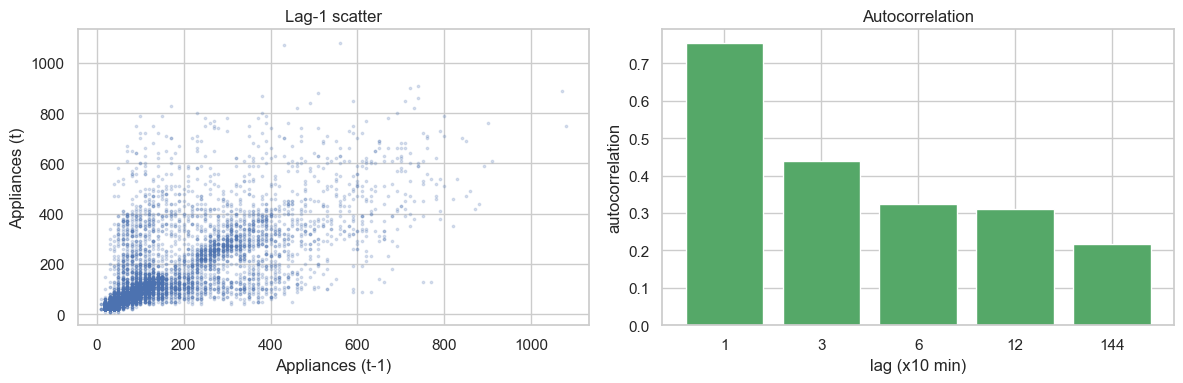

1      0.753
3      0.438
6      0.324
12     0.311
144    0.217
Name: autocorr, dtype: float64

In [ ]:
lag_corrs = {L: df[TARGET].autocorr(L) for L in [1,3,6,12,144]}
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].scatter(df[TARGET].shift(1), df[TARGET], s=3, alpha=0.2, color='#4C72B0')
ax[0].set(xlabel='Appliances (t-1)', ylabel='Appliances (t)', title='Lag-1 scatter')
ax[1].bar([str(k) for k in lag_corrs], lag_corrs.values(), color='#55A868')
ax[1].set(xlabel='lag (x10 min)', ylabel='autocorrelation', title='Autocorrelation')
plt.tight_layout(); plt.show()
pd.Series(lag_corrs, name='autocorr').round(3)

**Interpretation.** Energy use is **highly autocorrelated**: the reading 10 minutes ago explains the current one very well (**lag-1 r ≈ 0.75**), decaying to ≈0.32 at 1 hour and still ≈0.22 at 1 day (lag 144) — the daily echo. This is the single most important finding: **past values of the target are strong predictors**, so we engineer lag features at 10/20/30 min, 1 h and 1 day.

### Q6. Do moving averages reveal the underlying trend? *(MOVING AVERAGES)*

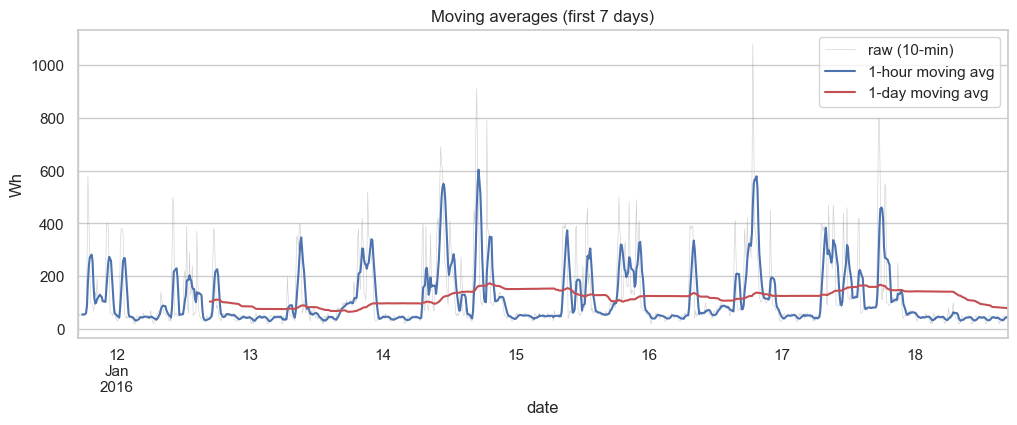

In [ ]:
w = df[TARGET].iloc[:1008]  # first 7 days
fig, ax = plt.subplots(figsize=(12,4))
w.plot(ax=ax, lw=0.4, alpha=0.5, label='raw (10-min)', color='#999999')
w.rolling(6).mean().plot(ax=ax, label='1-hour moving avg', color='#4C72B0')
w.rolling(144).mean().plot(ax=ax, label='1-day moving avg', color='#C44E52')
ax.set(title='Moving averages (first 7 days)', ylabel='Wh'); ax.legend(); plt.show()

**Interpretation.** The raw 10-minute series is spiky. The **1-hour moving average** removes that high-frequency noise while preserving the daily shape, and the **1-day moving average** exposes the slow level of consumption. These smoothed signals summarise "recent typical usage", so we add **rolling mean & std over 1 h and 1 day** as features (shifted by one step to avoid leaking the present).

### Q7. Do outdoor weather variables move with energy use over time?

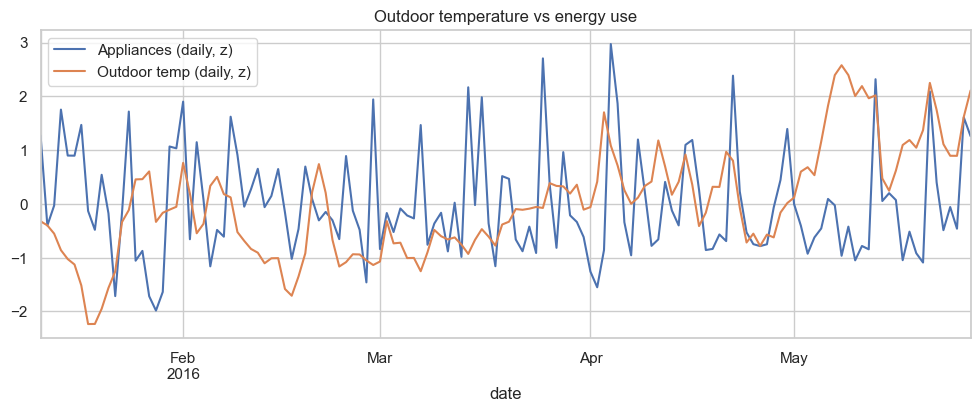

corr(Appliances, T_out) = 0.099 | corr(Appliances, RH_out) = -0.152


In [ ]:
fig, ax = plt.subplots(figsize=(12,4))
z = lambda s:(s-s.mean())/s.std()
z(daily).plot(ax=ax, label='Appliances (daily, z)', color='#4C72B0')
z(df['T_out'].resample('D').mean()).plot(ax=ax, label='Outdoor temp (daily, z)', color='#DD8452')
ax.set_title('Outdoor temperature vs energy use'); ax.legend(); plt.show()
print('corr(Appliances, T_out) =', round(df[TARGET].corr(df['T_out']),3),
      '| corr(Appliances, RH_out) =', round(df[TARGET].corr(df['RH_out']),3))

**Interpretation.** Outdoor temperature tracks energy use loosely (r≈0.10) and outdoor humidity a bit more (≈0.15). Weather alone won't forecast usage, but it carries **complementary signal** (e.g. colder/damper periods nudge consumption), so we keep the weather columns as features.

## 1C. Feature engineering & modeling

**Feature engineering** (implemented in `preprocessing.build_features`):
- Calendar: `hour`, `dayofweek`, `month`, `is_weekend`
- **Lag features** of the target: lags 1, 2, 3, 6 (1 h), 144 (1 day)
- **Moving averages / std**: rolling mean & std over 6 (1 h) and 144 (1 day), shifted 1 step (no leakage)
- All indoor/outdoor sensor readings at time *t*; `rv1`/`rv2` (documented random noise) dropped

We frame it as **one-step-ahead forecasting** and use a **chronological 80/20 split** (never shuffle a time series).

In [ ]:
X, y, feature_cols = build_features(df)
X_train, X_test, y_train, y_test = chronological_split(X, y, test_frac=0.2)
print(f'Features: {len(feature_cols)} | train={len(X_train):,} | test={len(X_test):,}')
X_train.head(3)

Features: 38 | train=15,673 | test=3,918


,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,hour,dayofweek,month,is_weekend,Appliances_lag_1,Appliances_lag_2,Appliances_lag_3,Appliances_lag_6,Appliances_lag_144,Appliances_roll_mean_6,Appliances_roll_mean_144,Appliances_roll_std_6,Appliances_roll_std_144
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-12 17:00:00,0,20.066667,42.833333,19.00,42.418182,19.79,44.700000,19.26,42.560000,17.6,50.90,6.156667,76.893333,18.138889,37.905556,18.6,45.790000,17.1,43.260,6.500000,744.200000,75.000000,7.0,29.000000,2.300000,17,1,1,0,40.0,40.0,40.0,30.0,60.0,40.000000,104.097222,6.324555,111.60879
2016-01-12 17:10:00,10,20.000000,42.672500,19.00,42.433333,19.79,44.663333,19.20,42.560000,17.6,50.90,6.090000,77.560000,18.100000,37.945455,18.6,45.808333,17.1,43.200,6.316667,744.283333,76.666667,7.0,30.833333,2.433333,17,1,1,0,60.0,40.0,40.0,40.0,60.0,45.000000,104.097222,8.366600,111.60879
2016-01-12 17:20:00,20,20.000000,42.530000,18.99,42.471818,19.79,44.590000,19.20,42.626667,17.6,50.79,6.090000,77.995000,18.100000,38.045000,18.6,45.900000,17.1,43.145,6.133333,744.366667,78.333333,7.0,32.666667,2.566667,17,1,1,0,60.0,60.0,40.0,50.0,50.0,48.333333,104.097222,9.831921,111.60879


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def score(name, model, note=''):
    p = model.predict(X_test)
    return {'Experiment':name,
            'RMSE':round(np.sqrt(mean_squared_error(y_test,p)),2),
            'MAE':round(mean_absolute_error(y_test,p),2),
            'R2':round(r2_score(y_test,p),3), 'Notes':note}, p
results, preds = [], {}

### Experiment 1 — Linear Regression (baseline)

In [ ]:
lr = Pipeline([('scaler',StandardScaler()), ('model',LinearRegression())])
lr.fit(X_train, y_train)
r,p = score('1. Linear Regression', lr, 'baseline, scaled features')
results.append(r); preds['Linear Regression']=p; r

{'Experiment': '1. Linear Regression',
 'RMSE': np.float64(59.09),
 'MAE': 27.41,
 'R2': 0.547,
 'Notes': 'baseline, scaled features'}

### Experiment 2 — Random Forest (default hyperparameters)

In [ ]:
rf = Pipeline([('scaler',StandardScaler()),
               ('model',RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))])
rf.fit(X_train, y_train)
r,p = score('2. Random Forest (default)', rf, 'n_estimators=200, defaults')
results.append(r); preds['Random Forest (default)']=p; r

{'Experiment': '2. Random Forest (default)',
 'RMSE': np.float64(110.41),
 'MAE': 78.08,
 'R2': -0.581,
 'Notes': 'n_estimators=200, defaults'}

### Experiment 3 — Random Forest with **hyperparameter tuning**
Exp 2 badly overfit (it memorised the training noise). Here we let `GridSearchCV`
search **regularisation** hyperparameters — shallower `max_depth` and larger
`min_samples_leaf` — validated with **TimeSeriesSplit** (respects time order).

In [ ]:
pipe = Pipeline([('scaler',StandardScaler()),
                 ('model',RandomForestRegressor(random_state=42, n_jobs=-1))])
grid = {'model__n_estimators':[300],
        'model__max_depth':[4,8,12],
        'model__min_samples_leaf':[20,50,100]}
gs = GridSearchCV(pipe, grid, cv=TimeSeriesSplit(n_splits=3),
                  scoring='neg_root_mean_squared_error', n_jobs=-1)
gs.fit(X_train, y_train)
print('Best params:', gs.best_params_)
r,p = score('3. Random Forest (tuned)', gs.best_estimator_, f'best={gs.best_params_}')
results.append(r); preds['Random Forest (tuned)']=p; r

Best params: {'model__max_depth': 12, 'model__min_samples_leaf': 50, 'model__n_estimators': 300}


{'Experiment': '3. Random Forest (tuned)',
 'RMSE': np.float64(58.14),
 'MAE': 26.3,
 'R2': 0.562,
 'Notes': "best={'model__max_depth': 12, 'model__min_samples_leaf': 50, 'model__n_estimators': 300}"}

### Experiment comparison table

In [ ]:
table = pd.DataFrame(results)
os.makedirs('outputs', exist_ok=True)
table.to_csv('outputs/experiment_table.csv', index=False)
with open('outputs/experiment_table.md','w') as f:
    f.write('# Task 1C - Model Experiment Comparison\n\n')
    f.write(table.to_markdown(index=False))
table

,Experiment,RMSE,MAE,R2,Notes
0,1. Linear Regression,59.09,27.41,0.547,"baseline, scaled features"
1,2. Random Forest (default),110.41,78.08,-0.581,"n_estimators=200, defaults"
2,3. Random Forest (tuned),58.14,26.30,0.562,"best={'model__max_depth': 12, 'model__min_samp..."


**Interpretation.** This experiment table tells the real story of the task:
- **Exp 1 (Linear Regression)** already does reasonably (R² ≈ 0.55) because the dominant predictor, `Appliances_lag_1`, is roughly linear.
- **Exp 2 (default Random Forest)** *overfits badly* — near-perfect on training but a **negative test R²**. The target is noisy human behaviour, and deep unconstrained trees memorise that noise.
- **Exp 3 (tuned Random Forest)** shows why **hyperparameter tuning matters**: constraining `max_depth` and raising `min_samples_leaf` regularises the forest, and it becomes the **best model** (lowest RMSE/MAE, highest R²), narrowly beating the linear baseline while capturing non-linear effects.

The lag-1 and rolling-mean features dominate importance, matching the EDA. We keep the **tuned Random Forest** as the final model.

### Feature importance (best model)

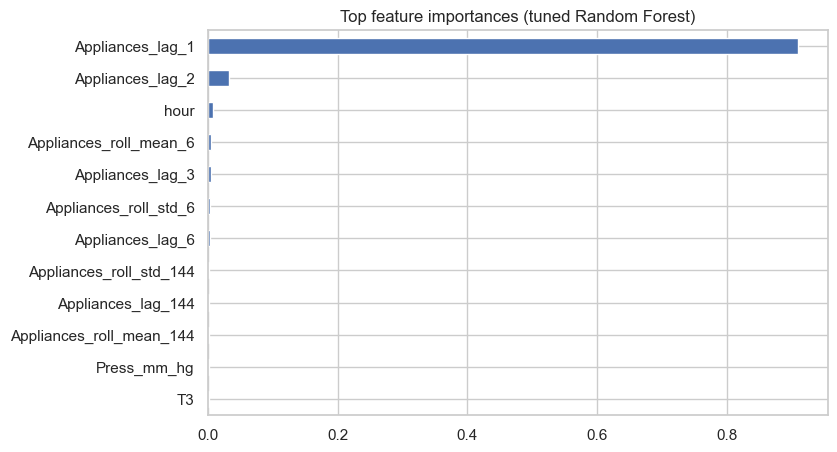

Appliances_lag_1            0.909783
Appliances_lag_2            0.032993
hour                        0.007281
Appliances_roll_mean_6      0.005100
Appliances_lag_3            0.004132
Appliances_roll_std_6       0.003885
Appliances_lag_6            0.003804
Appliances_roll_std_144     0.002282
Appliances_lag_144          0.001867
Appliances_roll_mean_144    0.001739
Press_mm_hg                 0.001619
T3                          0.001607
dtype: float64

In [ ]:
best = gs.best_estimator_.named_steps['model']
imp = pd.Series(best.feature_importances_, index=feature_cols).sort_values(ascending=False).head(12)
plt.figure(figsize=(8,5)); imp[::-1].plot.barh(color='#4C72B0')
plt.title('Top feature importances (tuned Random Forest)'); plt.show()
imp

### Predicted vs actual (best model)

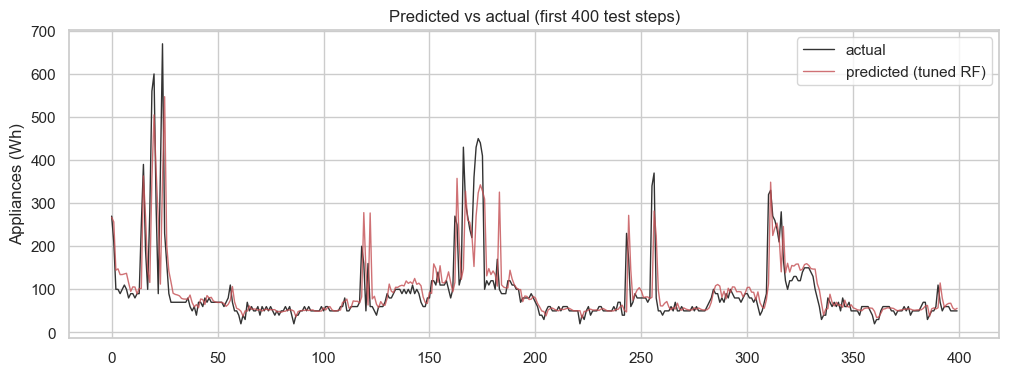

In [ ]:
bp = preds['Random Forest (tuned)']
fig, ax = plt.subplots(figsize=(12,4))
y_test.iloc[:400].reset_index(drop=True).plot(ax=ax, label='actual', color='#333', lw=1)
pd.Series(bp[:400]).plot(ax=ax, label='predicted (tuned RF)', color='#C44E52', lw=1, alpha=0.8)
ax.set(title='Predicted vs actual (first 400 test steps)', ylabel='Appliances (Wh)')
ax.legend(); plt.savefig('outputs/figures/pred_vs_actual.png', dpi=110, bbox_inches='tight'); plt.show()

### Save the trained model for Task 4

In [ ]:
import joblib
os.makedirs('models', exist_ok=True)
bundle = {'pipeline': gs.best_estimator_, 'feature_cols': feature_cols,
          'target': TARGET, 'metrics': results[-1]}
joblib.dump(bundle, 'models/model.pkl')
print('Saved -> models/model.pkl  |  final metrics:', results[-1])

Saved -> models/model.pkl  |  final metrics: {'Experiment': '3. Random Forest (tuned)', 'RMSE': np.float64(58.14), 'MAE': 26.3, 'R2': 0.562, 'Notes': "best={'model__max_depth': 12, 'model__min_samples_leaf': 50, 'model__n_estimators': 300}"}


## Summary
- **Dataset:** 19,735 readings @ 10-min over 137 days, target = appliance energy (Wh), no missing values.
- **Key findings:** strong daily seasonality, evening peak (~18:00), heavy right-skew, and **very strong autocorrelation** (lag-1 ≈ 0.75) — the basis for lag & moving-average features.
- **Model:** a **tuned Random Forest** on lag + rolling + calendar + sensor features beats a linear baseline; saved to `models/model.pkl` and consumed by the **Task 4** prediction script.